# MPC - grey-box

This script runs an optimal MPC (using casadi) for the 1/4 drone case study, using a continuous-time state-space grey-box model identified.

In [7]:
# 1. Imports and Definitions
import numpy as np
import matplotlib.pyplot as plt
import time
from tqdm.auto import tqdm
from casadi import SX, MX, DM, Function, nlpsol, vertcat, integrator, sqrt

Ts = 0.05  # Sampling time in seconds
nx = 2


In [8]:
# 2. CasADi state-space grey-box model (Manual RK4 for speedup)
c1 = -8.29151533
c2 = 0.00418887
c3 = -1.43673669

x = SX.sym('x', nx)
u_sym = SX.sym('u')

# Continuous time ODE
def f_dyn(x_vec, u_val):
    return vertcat(x_vec[1], c1*np.sin(x_vec[0]) + c2*u_val*sqrt(u_val**2 + 1e-4) + c3*x_vec[1])

# Manual RK4 integrator (much faster symbolic Hessian than CasADi's integrator())
k1 = f_dyn(x, u_sym)
k2 = f_dyn(x + Ts/2 * k1, u_sym)
k3 = f_dyn(x + Ts/2 * k2, u_sym)
k4 = f_dyn(x + Ts * k3, u_sym)
x_next = x + Ts/6 * (k1 + 2*k2 + 2*k3 + k4)
y_k = x_next[0]

F = Function('F', [x, u_sym], [x_next, y_k], ['x0', 'p'], ['xf', 'yk'])


In [ ]:
# 3. MPC Setup
N = 20
data = {
    'Ts': Ts,
    'x0': np.zeros(nx),
    'u_min': np.array([-100.0]),
    'u_max': np.array([100.0]),
    'u_guess': np.array([1.0]),
    'x_guess': np.zeros(nx),
    'tol': 1e-8,
}

def vcat(lst):
    return vertcat(*[DM(x) if not hasattr(x, 'is_symbolic') else x for x in lst])

w, lbw, ubw, w0 = [], [], [], []
g, lbg, ubg = [], [], []
J = 0

xk_param = MX.sym('xk_param', nx)
Pref = MX.sym('Pref', N)
u_prev_param = MX.sym('u_prev_param', 1)

xk = MX.sym('x0', nx)
w.append(xk)
lbw.append(np.full(nx, -np.inf))
ubw.append(np.full(nx, np.inf))
w0.append(data['x_guess'])

g.append(xk - xk_param)
lbg.append(np.zeros(nx))
ubg.append(np.zeros(nx))

for k in range(N):
    uk = MX.sym(f'u_{k}', 1)
    w.append(uk)
    lbw.append(data['u_min'])
    ubw.append(data['u_max'])
    w0.append(data['u_guess'])
    
    Fk = F(x0=xk, p=uk)
    xnext = Fk['xf']
    yk = Fk['yk'] * 180.0 / np.pi  # Convert angle to degrees for cost function
    
    if k == 0:
        du = uk - u_prev_param
    else:
        du = uk - u_prev
    u_prev = uk
    
    J = J + 1e3 * (yk - Pref[k])**2 + 10 * uk**2 + 200 * du**2
    
    xk = MX.sym(f'x_{k+1}', nx)
    w.append(xk)
    lbw.append(np.full(nx, -np.inf))
    ubw.append(np.full(nx, np.inf))
    w0.append(data['x_guess'])
    
    g.append(xk - xnext)
    lbg.append(np.zeros(nx))
    ubg.append(np.zeros(nx))

w = vertcat(*w)
lbw = vcat(lbw)
ubw = vcat(ubw)
w0 = vcat(w0)
g = vertcat(*g)
lbg = vcat(lbg)
ubg = vcat(ubg)

nlp = {'x': w, 'g': g, 'f': J, 'p': vertcat(xk_param, Pref, u_prev_param)}
solver = nlpsol('solver', 'ipopt', nlp, {'ipopt.print_level': 0, 'print_time': 0})


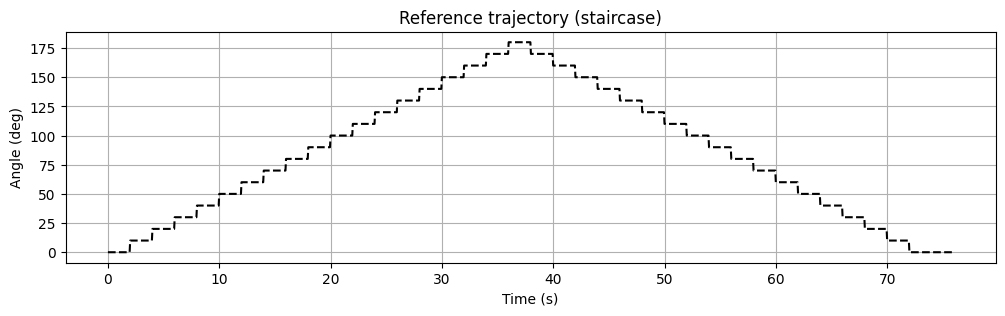

In [10]:
# 4. Reference Sequence Generation
T_sim = 75.0
steps = int(T_sim / Ts)
t_steps = np.arange(0, T_sim + N*Ts, Ts)

def get_ref(t):
    step = int(t // 2)
    if step <= 18:
        return step * 10.0
    else:
        return max(180.0 - (step - 18) * 10.0, 0.0)

x2ref_full = np.array([get_ref(t) for t in t_steps])
tvec = np.arange(0, T_sim, Ts)

plt.figure(figsize=(12, 3))
plt.plot(t_steps, x2ref_full, 'k--')
plt.title('Reference trajectory (staircase)')
plt.ylabel('Angle (deg)'); plt.xlabel('Time (s)')
plt.grid(True); plt.show()


In [11]:
# 5. Simulation Loop
xsim = np.zeros((nx, 1))
ysim = []
usim = []
tvec_sim = []
dtvec = []
u_prev_sim = 0.0

w0_val = w0.full().flatten()

for k in tqdm(range(steps), desc="MPC Simulation"):
    t = k * Ts
    ref_window = x2ref_full[k : k + N]
    
    pval = np.concatenate([xsim[:, -1], ref_window, [u_prev_sim]])
    
    tic = time.perf_counter()
    sol = solver(x0=w0_val, lbx=lbw, ubx=ubw, lbg=lbg, ubg=ubg, p=pval)
    dtvec.append(time.perf_counter() - tic)
    
    w_opt = sol['x'].full().flatten()
    u_opt = w_opt[nx]
    
    # Open Loop Simulation using model F
    sim_step = F(x0=xsim[:, -1], p=u_opt)
    xk1 = sim_step['xf'].full().flatten()
    yk = sim_step['yk'].full().item() * 180.0 / np.pi
    
    xsim = np.c_[xsim, xk1]
    usim.append(u_opt)
    ysim.append(yk)
    tvec_sim.append(t)
    
    # Warm start
    w0_val = w_opt
    u_prev_sim = u_opt


MPC Simulation: 100%|██████████| 1500/1500 [00:09<00:00, 163.79it/s]


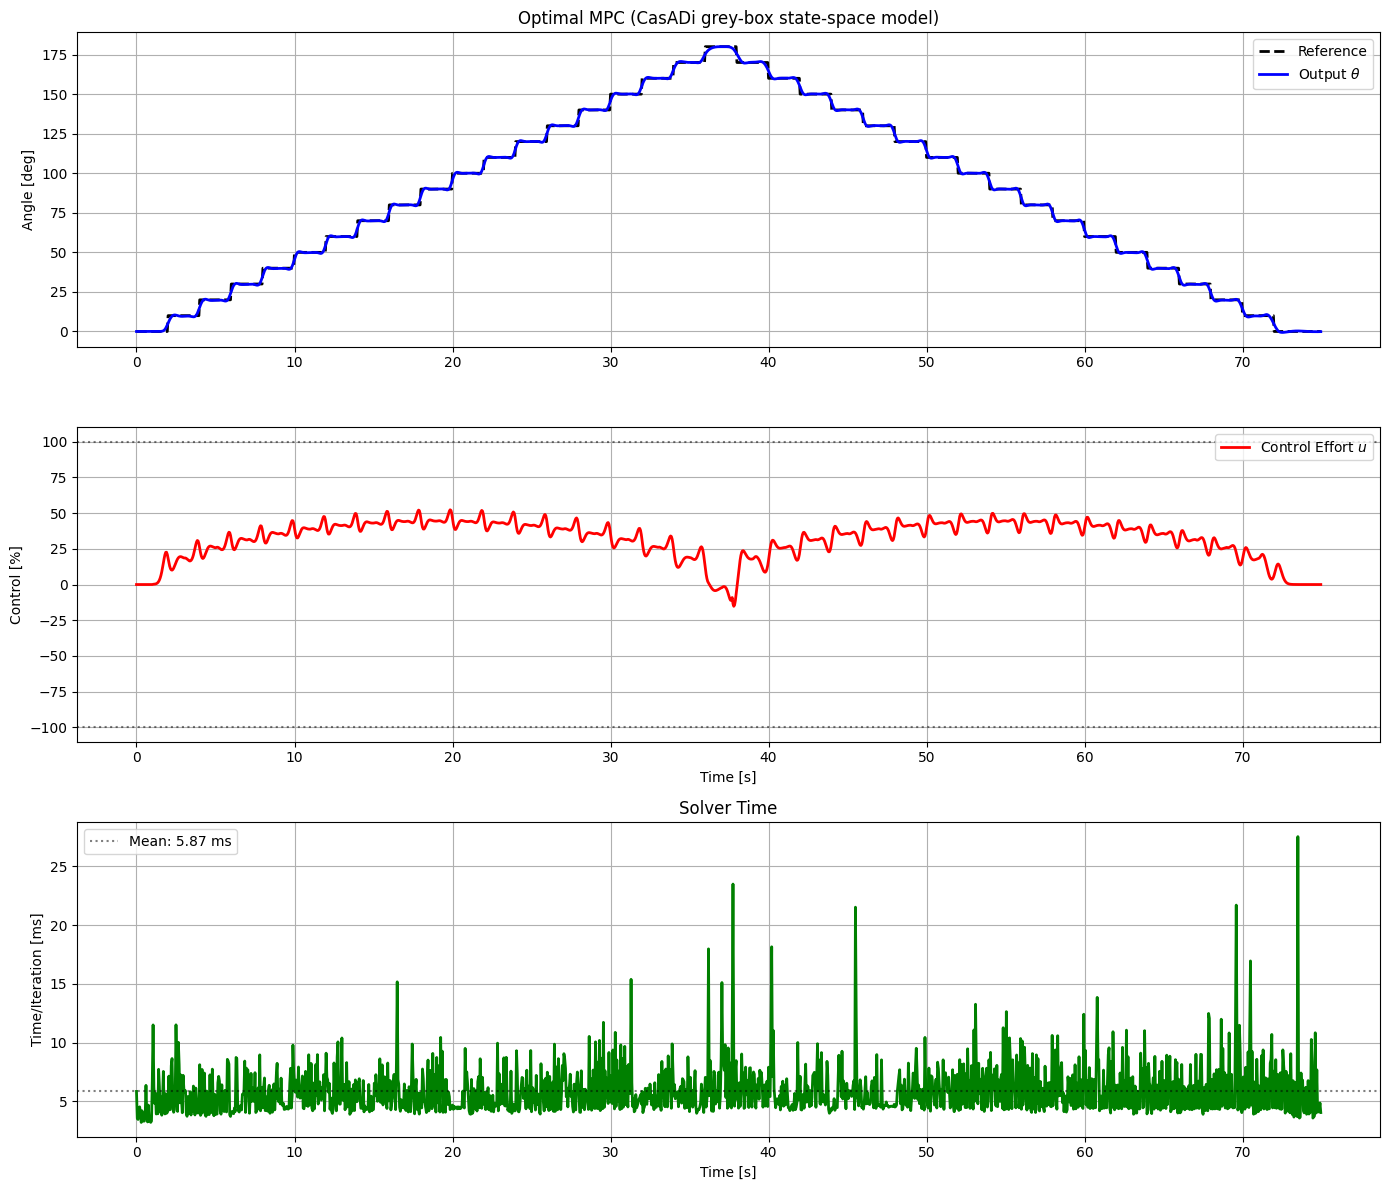

In [12]:
# 6. Plotting Results
plt.figure(figsize=(14, 12))
plt.subplot(3, 1, 1)
plt.plot(tvec_sim, x2ref_full[:steps], 'k--', label='Reference', lw=2)
plt.plot(tvec_sim, ysim, 'b-', label='Output $\\theta$', lw=2)
plt.ylabel('Angle [deg]')
plt.title('Optimal MPC (CasADi grey-box state-space model)')
plt.grid(True)
plt.legend()

plt.subplot(3, 1, 2)
plt.plot(tvec_sim, usim, 'r-', label='Control Effort $u$', lw=2)
plt.axhline(data['u_max'][0], color='k', ls=':', alpha=0.5)
plt.axhline(data['u_min'][0], color='k', ls=':', alpha=0.5)
plt.ylabel('Control [%]')
plt.xlabel('Time [s]')
plt.grid(True)
plt.legend()


plt.subplot(3, 1, 3)
plt.plot(tvec_sim, np.array(dtvec) * 1000, 'g-', lw=2)
plt.axhline(np.mean(dtvec) * 1000, color='k', ls=':', alpha=0.5, label=f'Mean: {np.mean(dtvec)*1000:.2f} ms')
plt.ylabel('Time/Iteration [ms]')
plt.xlabel('Time [s]')
plt.title('Solver Time')
plt.grid(True)
plt.legend()

plt.tight_layout()
plt.show()
